Final Capstone Project on Data Analysis with Python

Institution: Datanomics-Tech

Group-2:

        - Daniel Yimer
    
        - Hayat Ahmed
    
        - Menebre W.Desalegn
    
        - Solomon Kefale
    
        - Yohannes Million

Date: February 28, 2026

Dataset Source: https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data

# Amazon Sales Data Analysis

   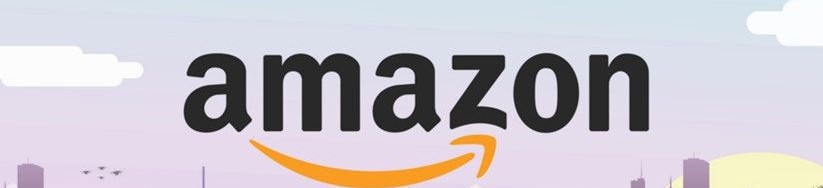

## 1. Introduction
The e-commerce industry needs data-driven decision-making because it helps businesses to increase sales and improve their operational processes and customer satisfaction levels. The daily operation of online marketplaces creates huge amounts of transactional data which businesses use to understand customer patterns and product needs and delivery success rates and various market areas.

The capstone project examines an e-commerce sales dataset from Amazon (India) which contains 128,975 transaction records. The dataset contains 128,975 records which show individual orders with complete details about the order date and product category and size and quantity and sales amount and fulfillment type and shipping location and promotion usage and order status.

### 1.1.  Data Dictionary (column description) and Problem Statement 

#### 1.1.1. Data Dictionary (column description):
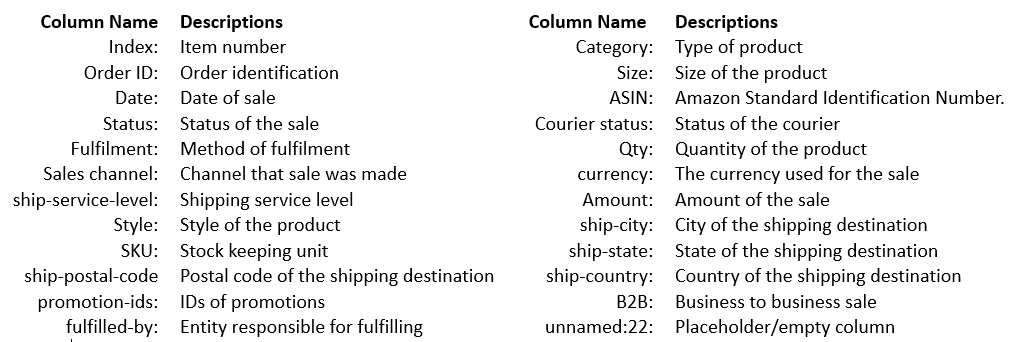

#### 1.1.2. Problem Statement
The Amazon (India) sales dataset contains extensive transactional data, but the absence of structured analysis prevents evaluation of complete sales performance and regional demand patterns and product profitability and operational efficiency. The business needs to conduct an in-depth analysis to determine which product categories perform best and which regions generate the most revenue and which fulfillment methods work most effectively and which reasons lead to order cancellations.

The organization needs data-driven insights to establish an effective inventory planning system and develop its marketing strategy and enhance its operational processes. The project will analyze the dataset through systematic methods to identify performance indicators which will lead to practical business recommendations.

### 1.2. Objectives of the Project

        - To analyze overall sales performance
        
        - To identify top-performing product categories and sizes
        
        - To examine geographic sales distribution
        
        - To evaluate order status and cancellation patterns
        
        - To assess fulfillment performance
        
        - To analyze the impact of promotions and B2B transactions
        
        - To provide actionable business recommendations

In [1]:
# Import the necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read the file 
amazon_df = pd.read_csv('Amazon Sale Report.csv')

## 2. Understanding the dataset

In [3]:
# Read the first 5 rows of the dataset
amazon_df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [4]:
# Determine the shape of the dataset
amazon_df.shape

(128975, 24)

In [5]:
# Explor the column names
amazon_df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [6]:
# Explor the information of the dataset
amazon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [7]:
# Check for the duplicate values for each variable
amazon_df.duplicated().sum()

np.int64(0)

In [8]:
# Explor the unique values in each columns of the dataframe
amazon_df.nunique().to_frame(name='No. of unique values')

,No. of unique values
index,128975
Order ID,120378
Date,91
Status,13
Fulfilment,2
Sales Channel,2
ship-service-level,2
Style,1377
SKU,7195
Category,9


In [9]:
# Check for the null values of the dataset
amazon_df.isna().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [10]:
# Explor the statistcal values of the dataset for numeric columns before cleaning 
amazon_df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,128975.0,64487.000000,37232.019822,0.0,32243.5,64487.0,96730.5,128974.0
Qty,128975.0,0.904431,0.313354,0.0,1.0,1.0,1.0,15.0
Amount,121180.0,648.561465,281.211687,0.0,449.0,605.0,788.0,5584.0
ship-postal-code,128942.0,463966.236509,191476.764941,110001.0,382421.0,500033.0,600024.0,989898.0


## 3. Data Cleaning

In [11]:
# Standardize the some of the column names
amazon_df.columns = amazon_df.columns.str.lower()
amazon_df = amazon_df.rename(columns={'sku':'SKU', 'asin':'ASIN', 'b2b':'B2B'})
amazon_df.columns = amazon_df.columns.str.replace(' ', '_')
amazon_df.columns = amazon_df.columns.str.replace('-', '_')
amazon_df.columns = amazon_df.columns.str.replace('_$', '', regex=True)
amazon_df.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'SKU', 'category', 'size', 'ASIN',
       'courier_status', 'qty', 'currency', 'amount', 'ship_city',
       'ship_state', 'ship_postal_code', 'ship_country', 'promotion_ids',
       'B2B', 'fulfilled_by', 'unnamed:_22'],
      dtype='object')

In [12]:
# Drop unnecessary columns
amazon_df = amazon_df.drop(columns=['index', 'ship_country', 'ship_postal_code','fulfilled_by', 'unnamed:_22'])

In [13]:
# Handling missing data in courier_status, amount, currency, ship_city, ship_state, promotion_ids
## Handling missing data in currency
amazon_df['currency'].fillna('INR', inplace=True) 

## Handling missing data in promotion_ids, ship_city and ship_state
amazon_df.fillna({'ship_city': 'Unknown', 'ship_state': 'Unknown'}, inplace=True)
amazon_df['promotion_ids'].fillna('No promotion', inplace=True)

In [14]:
## Handling missing in courier_status
### Check percentage values of state and courier_status match
amazon_df[amazon_df['courier_status'].isna()]['status'].value_counts(normalize=True, dropna=False)*100

status
Cancelled                       99.839930
Shipped - Delivered to Buyer     0.116414
Shipped - Returned to Seller     0.043655
Name: proportion, dtype: float64

In [15]:
###---> Have 3 conditions cancelled, returned and delivered
### Let's match and assign
cancelled = (amazon_df['courier_status'].isna()) & (amazon_df['status'] == 'Cancelled')
amazon_df.loc[cancelled, 'courier_status'] = 'Cancelled'

returned = (amazon_df['courier_status'].isna()) & (amazon_df['status'] == 'Shipped - Returned to Seller')
amazon_df.loc[returned, 'courier_status'] = 'Returned'

delivered = (amazon_df['courier_status'].isna()) & (amazon_df['status'] == 'Shipped - Delivered to Buyer')
amazon_df.loc[delivered, 'courier_status'] = 'Delivered'

In [16]:
## Handling missing values in amount
### Check all the missing amount values are matched with courier_states that is cancelled
amazon_df[amazon_df['amount'].isna()]['courier_status'].value_counts()

courier_status
Cancelled    7660
Unshipped     124
Delivered       8
Returned        3
Name: count, dtype: int64

In [17]:
### Cancelled and unshiped makes the amount to be zero
cancelled_val = (amazon_df['amount'].isna()) & (amazon_df['courier_status'] == 'Cancelled')
amazon_df.loc[cancelled_val, 'amount'] = 0

unshipped = (amazon_df['amount'].isna()) & (amazon_df['courier_status'] == 'Unshipped')
amazon_df.loc[unshipped, 'amount'] = 0

### For the amount where courier_status is delivered and/or returned --> drop the values
drop_val = amazon_df[(amazon_df['amount'].isna()) & 
                     (amazon_df['courier_status'].isin(['Delivered', 'Returned']))].index

amazon_df = amazon_df.drop(drop_val)

In [18]:
amazon_df.isna().sum()

order_id              0
date                  0
status                0
fulfilment            0
sales_channel         0
ship_service_level    0
style                 0
SKU                   0
category              0
size                  0
ASIN                  0
courier_status        0
qty                   0
currency              0
amount                0
ship_city             0
ship_state            0
promotion_ids         0
B2B                   0
dtype: int64

In [19]:
# Create a new binary column based on whether promotion_ids for better analysis
## Create 'promotion_status' column where no for no promotion and yes for other.
def check_promotion(value):
    if value == 'No promotion':
        return 'No'
    else:
        return 'Yes'

amazon_df['promotion_status'] = amazon_df['promotion_ids'].apply(check_promotion)

In [20]:
amazon_df.shape

(128964, 20)

In [21]:
# Change the date data type to datetime
amazon_df['date'] = pd.to_datetime(amazon_df['date'], errors='coerce')
print(amazon_df['date'].dtype)

datetime64[ns]


In [22]:
# Explor the statistcal values of the dataset for numeric columns after cleaning 
amazon_df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,128964,2022-05-12 11:51:06.046338560,2022-03-31 00:00:00,2022-04-20 00:00:00,2022-05-10 00:00:00,2022-06-04 00:00:00,2022-06-29 00:00:00,NaN
qty,128964.0,0.904508,0.0,1.0,1.0,1.0,15.0,0.313256
amount,128964.0,609.415638,0.0,413.0,583.0,771.0,5584.0,313.309965


## 4. Exploring Data Analysis

In [23]:
# Extract month and days in a new column
amazon_df['month_name'] = amazon_df['date'].dt.month_name()
amazon_df['week_days'] = amazon_df['date'].dt.day_name()

### 4.1. KPI's

In [24]:
# Calculate KPI's (i.e. total revenue, total orders, total quantity sold, average order value, cancellation rate)
#amazon_df = amazon_df[amazon_df['status'] != 'Cancelled']
#total_revenue = amazon_df['amount'].sum()
exchange_rate = 0.011  # Feb. 17, 2026 1INR = 0.011$
total_revenue = amazon_df['amount'].sum() * exchange_rate
total_orders = amazon_df[amazon_df['status'] != 'Cancelled'].shape[0]
total_qty = amazon_df['qty'].sum()
average_order = total_revenue/total_orders
cancelled_orders = amazon_df[amazon_df['status'] == 'Cancelled'].shape[0]
cancelled_orders_rate = (cancelled_orders/total_orders)*100

print(f'Total Revenue = ${total_revenue:.2f}')
print(f'Total No. of Order = {total_orders:.2f}')
print(f'Total Qty Sold = {total_qty:.2f}')
print(f'Average Order Value = ${average_order:.2f}')
print(f'Cancelled Order Rate = {cancelled_orders_rate:.2f}%')

Total Revenue = $864519.46
Total No. of Order = 110632.00
Total Qty Sold = 116649.00
Average Order Value = $7.81
Cancelled Order Rate = 16.57%


### 4.2. Univariate Analysis

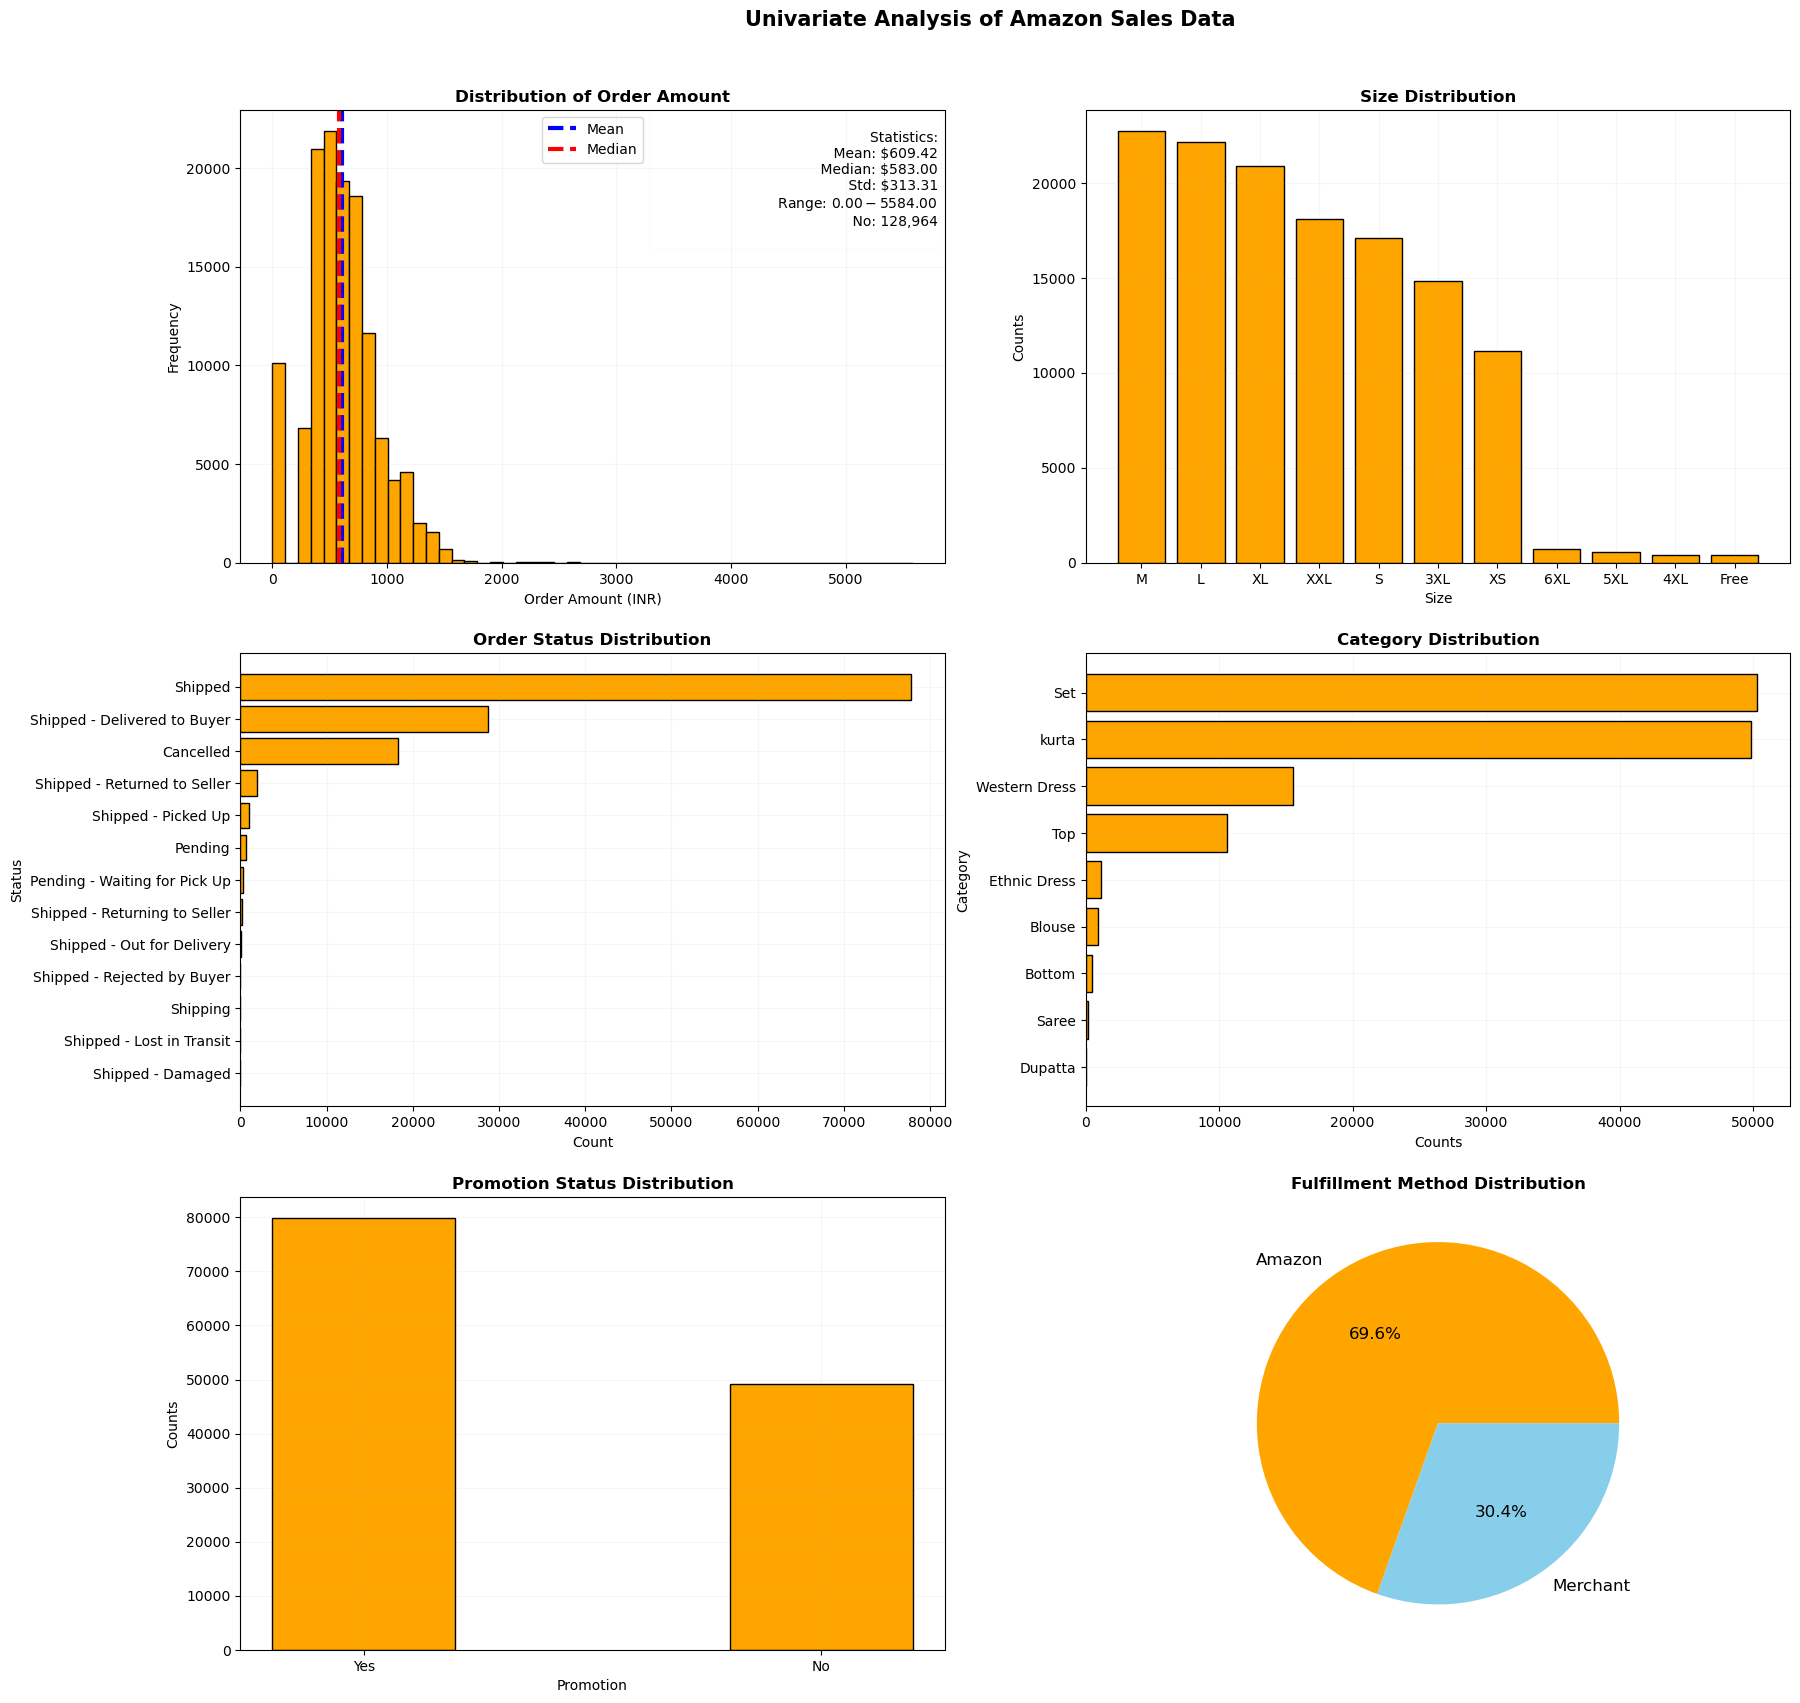

In [25]:
# Understand distributions, central tendency, spread, outliers

## Taking the sales, status, size, category, promotion ids and fulfillment method distribution 

# Create 3 by 3 subplots
fig, axes = plt.subplots(3,2, figsize=(20, 20))
fig.suptitle('Univariate Analysis of Amazon Sales Data', fontsize=15, fontweight='bold', y=0.93);

# 1. Sales Distribution Plot
axes[0, 0].hist(amazon_df['amount'], bins=50, color='orange', edgecolor='black')

# Display the mean and median line on the plot
amount=amazon_df['amount']
mean_amount = amount.mean()
median_amount = amount.median()
axes[0,0].axvline(mean_amount, color='blue', linestyle='--', linewidth=3, label ='Mean')
axes[0,0].axvline(median_amount, color='red', linestyle='--', linewidth=3, label ='Median')

# Display the title, x/y label, and grid
axes[0, 0].set_title('Distribution of Order Amount', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Order Amount (INR)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].legend(fontsize=10, loc='upper center')
axes[0, 0].grid(True, alpha=0.1)


# Display the statistical measurea and No. of datasets
stats_text1 = f'''
                Statistics:
                            Mean: ${mean_amount:.2f}
                            Median: ${median_amount:.2f}
                            Std: ${amount.std():.2f}
                            Range: ${amount.min():.2f} - ${amount.max():.2f}
                            No: {len(amount):,}
               '''

axes[0, 0].text(0.99, 0.99, stats_text1, transform=axes[0,0].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.01));

# 2.  Order Status Distribution 

status_counts = amazon_df['status'].value_counts().sort_values(ascending=True)

# Display the title, x/y label, and grid
axes[1, 0].barh(status_counts.index, status_counts.values, color='orange', edgecolor='black')
axes[1, 0].set_title('Order Status Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count', fontsize=10)
axes[1, 0].set_ylabel('Status', fontsize=10)
axes[1, 0].grid(True, alpha=0.1);

# 3. Size Distribution

size_counts = amazon_df['size'].value_counts()
axes[0, 1].bar(size_counts.index, size_counts.values, color= 'orange', edgecolor='black')

# Display the title, x/y label, and grid
axes[0, 1].set_title('Size Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Size', fontsize=10)
axes[0, 1].set_ylabel('Counts', fontsize=10)
axes[0, 1].grid(True, alpha=0.1);

# 4. Promotion Distribution 

promotion_counts = amazon_df['promotion_status'].value_counts()
axes[2, 0].bar(promotion_counts.index, promotion_counts.values, color='orange', edgecolor='black', width=0.4)

# Display the title, x/y label, and grid
axes[2, 0].set_title('Promotion Status Distribution', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Promotion', fontsize=10)
axes[2, 0].set_ylabel('Counts', fontsize=10)
axes[2, 0].grid(True, alpha=0.1);

# 5. Category Distribution
category_counts = amazon_df['category'].value_counts().sort_values(ascending=True)
axes[1, 1].barh(category_counts.index, category_counts.values, color = 'orange', edgecolor='black')

# Display the title, x/y label, and grid
axes[1, 1].set_title('Category Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Counts', fontsize=10)
axes[1, 1].set_ylabel('Category', fontsize=10)
axes[1, 1].grid(True, alpha=0.1);

# 6. Fulfillment Method Distribution 

fulfillment_count = amazon_df['fulfilment'].value_counts().reset_index()

# Display the title

axes[2, 1].pie(fulfillment_count['count'],labels=fulfillment_count['fulfilment'],autopct='%1.1f%%', 
               colors=['orange', 'skyblue'], textprops={'fontsize':12})
axes[2, 1].set_title('Fulfillment Method Distribution', fontsize=12, fontweight='bold');

**INTERPRETATIONS** 

*1) Distribution of Order Amount*

        - When order amounts increase, the number of orders declines sharply.
        - As the range goes upto 5584, there might be a bulk or premium orders.

*2) Order Status Distribution*

        - Shipped is the largest category, meaning  most orders are in transit.
        - Shipped_Delivered to Buyer  and shipped amount are highly apart which indicate many orders are in process.
        - There is significant amount of order cancellation. 


*3) Size Distribution*

        - The most demanded sizes are M, L, and XL and the least demanded sizes are 6XL,5XL,4XL, and free.
        - XXL, S, 3XL, and XS sizes are moderatly demanded.

*4) Category Distribution*

        - The most dominant categories are Sets and Kurtas followed by Western Dress and Top.
        - The business is dependent on a few categories. 
        
*5) Promotion Distribution*

        - When there is promotions, the number of orders increase. 

*6) Fulfillment Method Distribution*

        - Most or dominant amount of orders are filfulled directly by Amazon.     

**KEY INSIGHTS** 

    - Most orders are under 1000 with a long tail to the right(right-skewed).
    - Inventory should be weighted toward M–XL, but inclusivity in larger sizes is still important for premium/high-value customers.
    - The majority of orders progress through shipping and delivery, but cancellations are a major leakage point.
    - The product mix is heavily skewed toward Sets and Kurtas.
    - Nearly 60% of orders are linked to promotions, showing that customers are highly responsive to promotions like discounts or offers.
    - Amazon is the primary fulfillment channel, suggesting that customers may prefer its reliability, speed, or trust factor.

### 4.3. Bivariate Analysis 

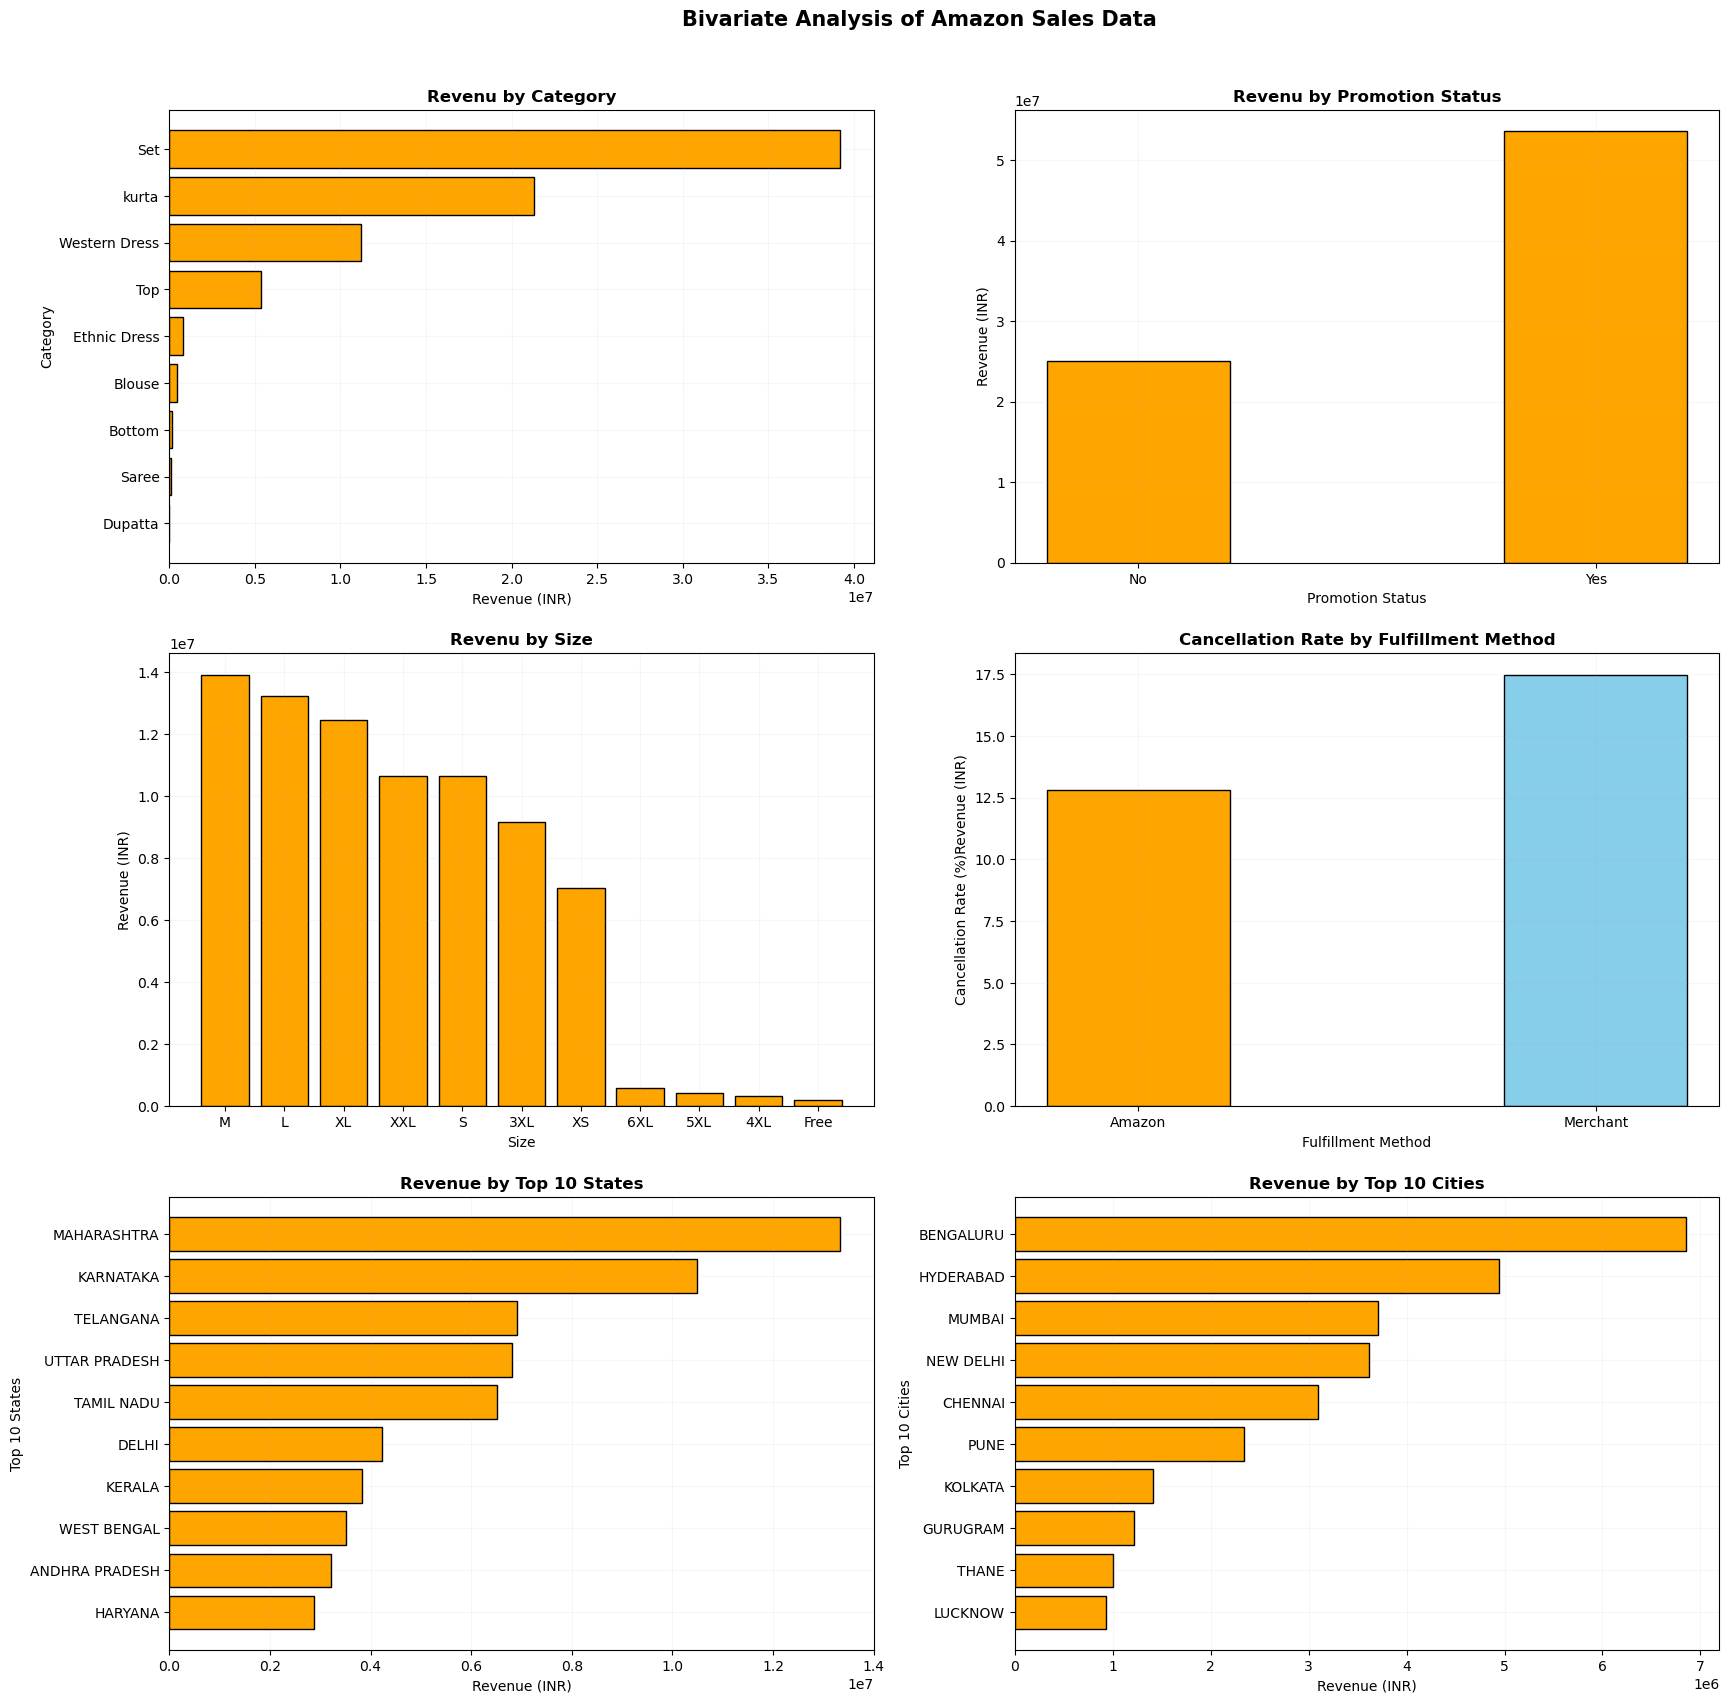

In [26]:
# Bivariate analysis to understand the relationship between two variables
##  Taking Revenue by  Category , Revenue by Size , Revenue by State (Top 10), Revenue by top 10 cities, 
### Revenue by Promotion and Cancellation Rate by Fulfillment Method 

# Create 3 by 3 subplots
fig, axes = plt.subplots(3,2, figsize=(20, 20))
fig.suptitle('Bivariate Analysis of Amazon Sales Data', fontsize=15, fontweight='bold', y=0.93);

# 1. Revenue by Category
# Group revenu(amount) by category
category_revenue = amazon_df.groupby('category')['amount'].sum().sort_values(ascending=True)
axes[0, 0].barh(category_revenue.index, category_revenue.values, color='orange', edgecolor='black')

# Display the title, x/y label, and grid
axes[0, 0].set_title('Revenu by Category', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Revenue (INR)', fontsize=10)
axes[0, 0].set_ylabel('Category', fontsize=10)
axes[0, 0].grid(True, alpha=0.1);

# 2. Revenue by promotion 
# Group revenu(amount) by promotion status
promo_revenue = amazon_df.groupby('promotion_status')['amount'].sum()

axes[0, 1].bar(promo_revenue.index.astype(str), promo_revenue.values, color='orange', edgecolor='black', width=0.4)

# Display the title, x/y label, and grid
axes[0, 1].set_title('Revenu by Promotion Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Promotion Status', fontsize=10)
axes[0, 1].set_ylabel('Revenue (INR)', fontsize=10)
axes[0, 1].grid(True, alpha=0.1);

# 3. Revenue by Size
# Group revenu(amount) by size
size_revenue = amazon_df.groupby('size')['amount'].sum().sort_values(ascending=False)
axes[1, 0].bar(size_revenue.index, size_revenue.values, color='orange', edgecolor='black')

# Display the title, x/y label, and grid
axes[1, 0].set_title('Revenu by Size', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Size', fontsize=10)
axes[1, 0].set_ylabel('Revenue (INR)', fontsize=10)
axes[1, 0].grid(True, alpha=0.1);

# 4.  Cancellation Rate by Fulfillment Method 
# Determine cancellation rate by fulfillment 
## Group the fulfilment and status and count how many orders
group_fulfil_status = amazon_df.groupby(['fulfilment', 'status']).size()

## Convert the grouped result into a table format
fulfillment_status = group_fulfil_status.unstack(fill_value=0)

# Now calculate cancellation rate
fulfillment_status['cancellation_rate'] = fulfillment_status['Cancelled'] / fulfillment_status.sum(axis=1)

axes[1, 1].bar(fulfillment_status.index, fulfillment_status['cancellation_rate']*100, color=['orange','skyblue'], edgecolor='black', width=0.4)

# Display the title, x/y label, and grid
axes[1, 1].set_title('Cancellation Rate by Fulfillment Method', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Fulfillment Method', fontsize=10)
axes[1, 1].set_ylabel('Cancellation Rate (%)Revenue (INR)', fontsize=10)
axes[1, 1].grid(True, alpha=0.1);

# 5. Revenue by top 10 ship states
# Group revenu(amount) by top 10 ship_state
state_revenue = amazon_df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10)
axes[2, 0].barh(state_revenue.index, state_revenue.values, color='orange', edgecolor='black')
axes[2, 0].invert_yaxis()

# Display the title, x/y label, and grid
axes[2, 0].set_title('Revenue by Top 10 States', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Revenue (INR)', fontsize=10)
axes[2, 0].set_ylabel('Top 10 States', fontsize=10)
axes[2, 0].grid(True, alpha=0.1);

# 6. Revenue by top 10 ship cities 
# Group revenu(amount) by top 10 ship_cities
city_revenue = amazon_df.groupby('ship_city')['amount'].sum().sort_values(ascending=False).head(10)
axes[2, 1].barh(city_revenue.index, city_revenue.values, color='orange', edgecolor='black')
axes[2, 1].invert_yaxis()

# Display the title, x/y label, and grid
axes[2, 1].set_title('Revenue by Top 10 Cities', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Revenue (INR)', fontsize=10)
axes[2, 1].set_ylabel('Top 10 Cities', fontsize=10)
axes[2, 1].grid(True, alpha=0.1);

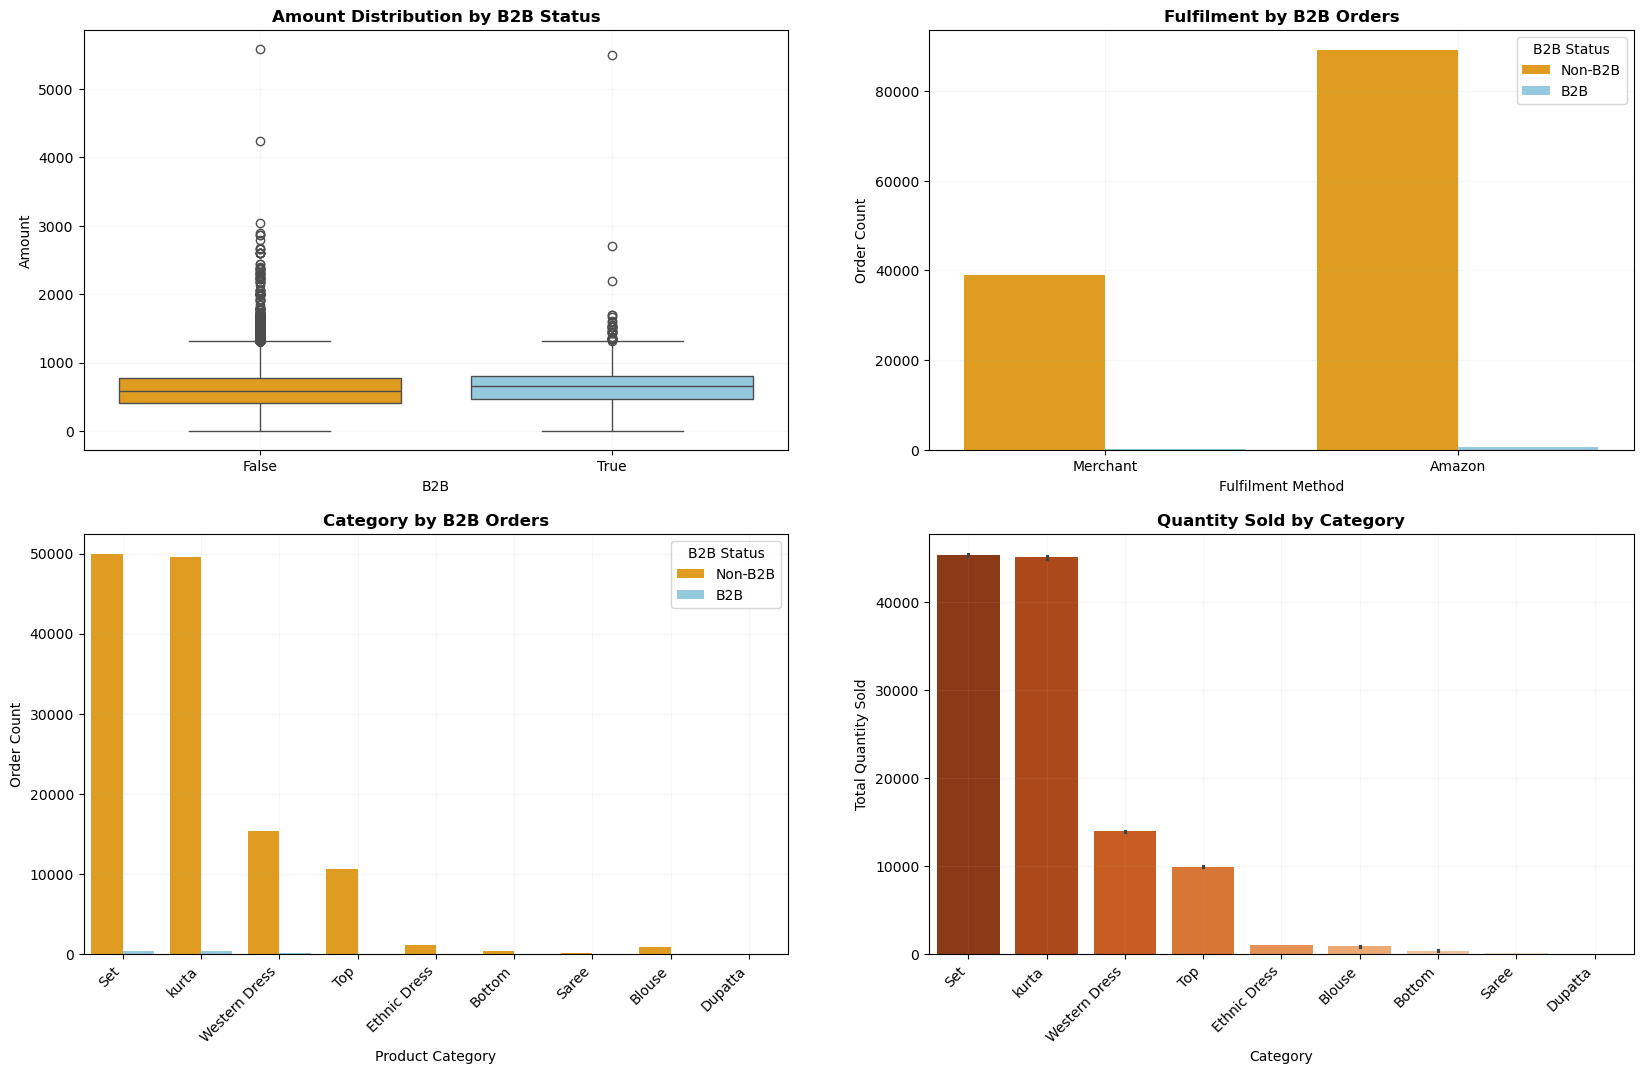

In [27]:
# Create 3 by 3 subplots
fig, axes = plt.subplots(2,2, figsize=(20, 12))

# 7. Amount by B2B
sns.boxplot(data=amazon_df, x='B2B', y='amount', ax=axes[0, 0],
            palette=['orange', 'skyblue'])

# Display the title, x/y label, and grid 
axes[0, 0].set_title('Amount Distribution by B2B Status', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('B2B', fontsize=10)
axes[0, 0].set_ylabel('Amount', fontsize=10)
axes[0, 0].grid(True, alpha=0.1)

# 8. Fulfilment by B2B
sns.countplot(data=amazon_df, x='fulfilment', hue='B2B', palette=['orange', 'skyblue'], ax=axes[0, 1])

# Display the title, x/y label, and grid 
axes[0, 1].set_title('Fulfilment by B2B Orders', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Fulfilment Method', fontsize=10)
axes[0, 1].set_ylabel('Order Count')
axes[0, 1].legend(title='B2B Status', labels=['Non-B2B', 'B2B'])
axes[0, 1].grid(True, alpha=0.1)

# 9. Category by B2B
sns.countplot(data=amazon_df, x='category', hue='B2B', palette=['orange', 'skyblue'], ax=axes[1, 0])

# Display the title, x/y label, and grid
axes[1, 0].set_title('Category by B2B Orders', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Product Category', fontsize=10)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
axes[1, 0].set_ylabel('Order Count', fontsize=10)
axes[1, 0].legend(title='B2B Status', labels=['Non-B2B', 'B2B'])
axes[1, 0].grid(True, alpha=0.1)

# 10. Category by Quantity
category_order = amazon_df.groupby('category')['qty'].sum().sort_values(ascending=False).index
orange_palette = sns.color_palette('Oranges', n_colors=len(amazon_df['category'].unique()))[::-1]
sns.barplot(data=amazon_df, x='category', y='qty', estimator=sum, palette=orange_palette, order=category_order, ax=axes[1,1])

# Display the title, x/y label, and grid
axes[1, 1].set_title('Quantity Sold by Category', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Category', fontsize=10)
axes[1, 1].set_ylabel('Total Quantity Sold', fontsize=10)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.1)

**INTERPRETATIONS** 

*1) Revenue by Category*

        - Sets and Kurtas have the largest influenc on the business.
        - Sales/Revenue is dependent on a few categories. 
        - Dupatta, Saree and Bottom are the least contributors to the revenue.

*2) Revenue by Promotion*

        - Products with promotions generate significantly more revenue than those without.

*3) Revenue by Size*

        - Medium (M) generates the highest revenue, followed by L, XL, and XXL.
        - Revenue steadily declines for both smaller (XS, S) and larger sizes (3XL–6XL). The Free size contributes the least.

*4) Cancellation Rate by Fulfillment Method*

        - The cancellation rate is significantly lower for Amazon fulfillment compared to Merchant fulfillment.
        
*5) Revenue by top 10 ship states*

        - Maharashtra, Karnataka, and Telangana are the top three states, generating the highest revenue.
        - Uttar Pradesh, Tamil Nadu, and Delhi also show significant revenue.
        - States like Kerala, West Bengal, Andhra Pradesh, and Haryana contribute less but still make the top 10.

*6) Revenue by top 10 ship cities*

        - Bengaluru and Hyderabad cities lead, followed by Mumbai and New Delhi.
        - Gurugram, Thane, and Lucknow generate less revenue but still rank in the top 10.

*7) Amount distribution by B2B status*

        - Both B2B and Non-B2B transactions have comparable median amounts, meaning that average deal sizes are not drastically different.
        - Both order groups have almost the same range.
        - Non-B2B orders have more extreme values/outliers, which means there are very large orders. 

*8) Fulfilment by B2B orders*

        - For both B2B and non-B2B orders, the Amazon fulfilment is dominant.
        - Non-B2B orders are more influential for both fulfilment methods, especially in Amazon.

*9) Category by B2B orders*

        - In all categories, non-B2B orders are dominant. 
        - Set and Kurta categories of non-B2B orders are the most dominant ones.

*10) Quantity by Category*

        - Set and Kurta are the  top two in total quantity sold, confirming they are the most popular categories by volume.
        - Western Dress and Top follow, while the categories Saree, Blouse, and Dupatta have much lower sales volumes.

**KEY INSIGHTS** 

    - Revenue is heavily concentrated in Sets and Kurtas, confirming them as the backbone of sales.
    - Promotions directly boost revenue. 
    - Merchant fulfillment faces more cancellations, which reduces reliability and customer trust, showing that Amazon is comparatively stronger in order completion.
    - Non-B2B orders show a wider spread and more outliers, that shows some very small and some very large transactions. While B2B are more consistent, with fewer extreme outliers, suggesting steadier transaction amounts.
    - The bulk of orders and revenue are generated by regular shoppers buying for personal use(non-B2B).

### 4.4. Multivariate Analysis

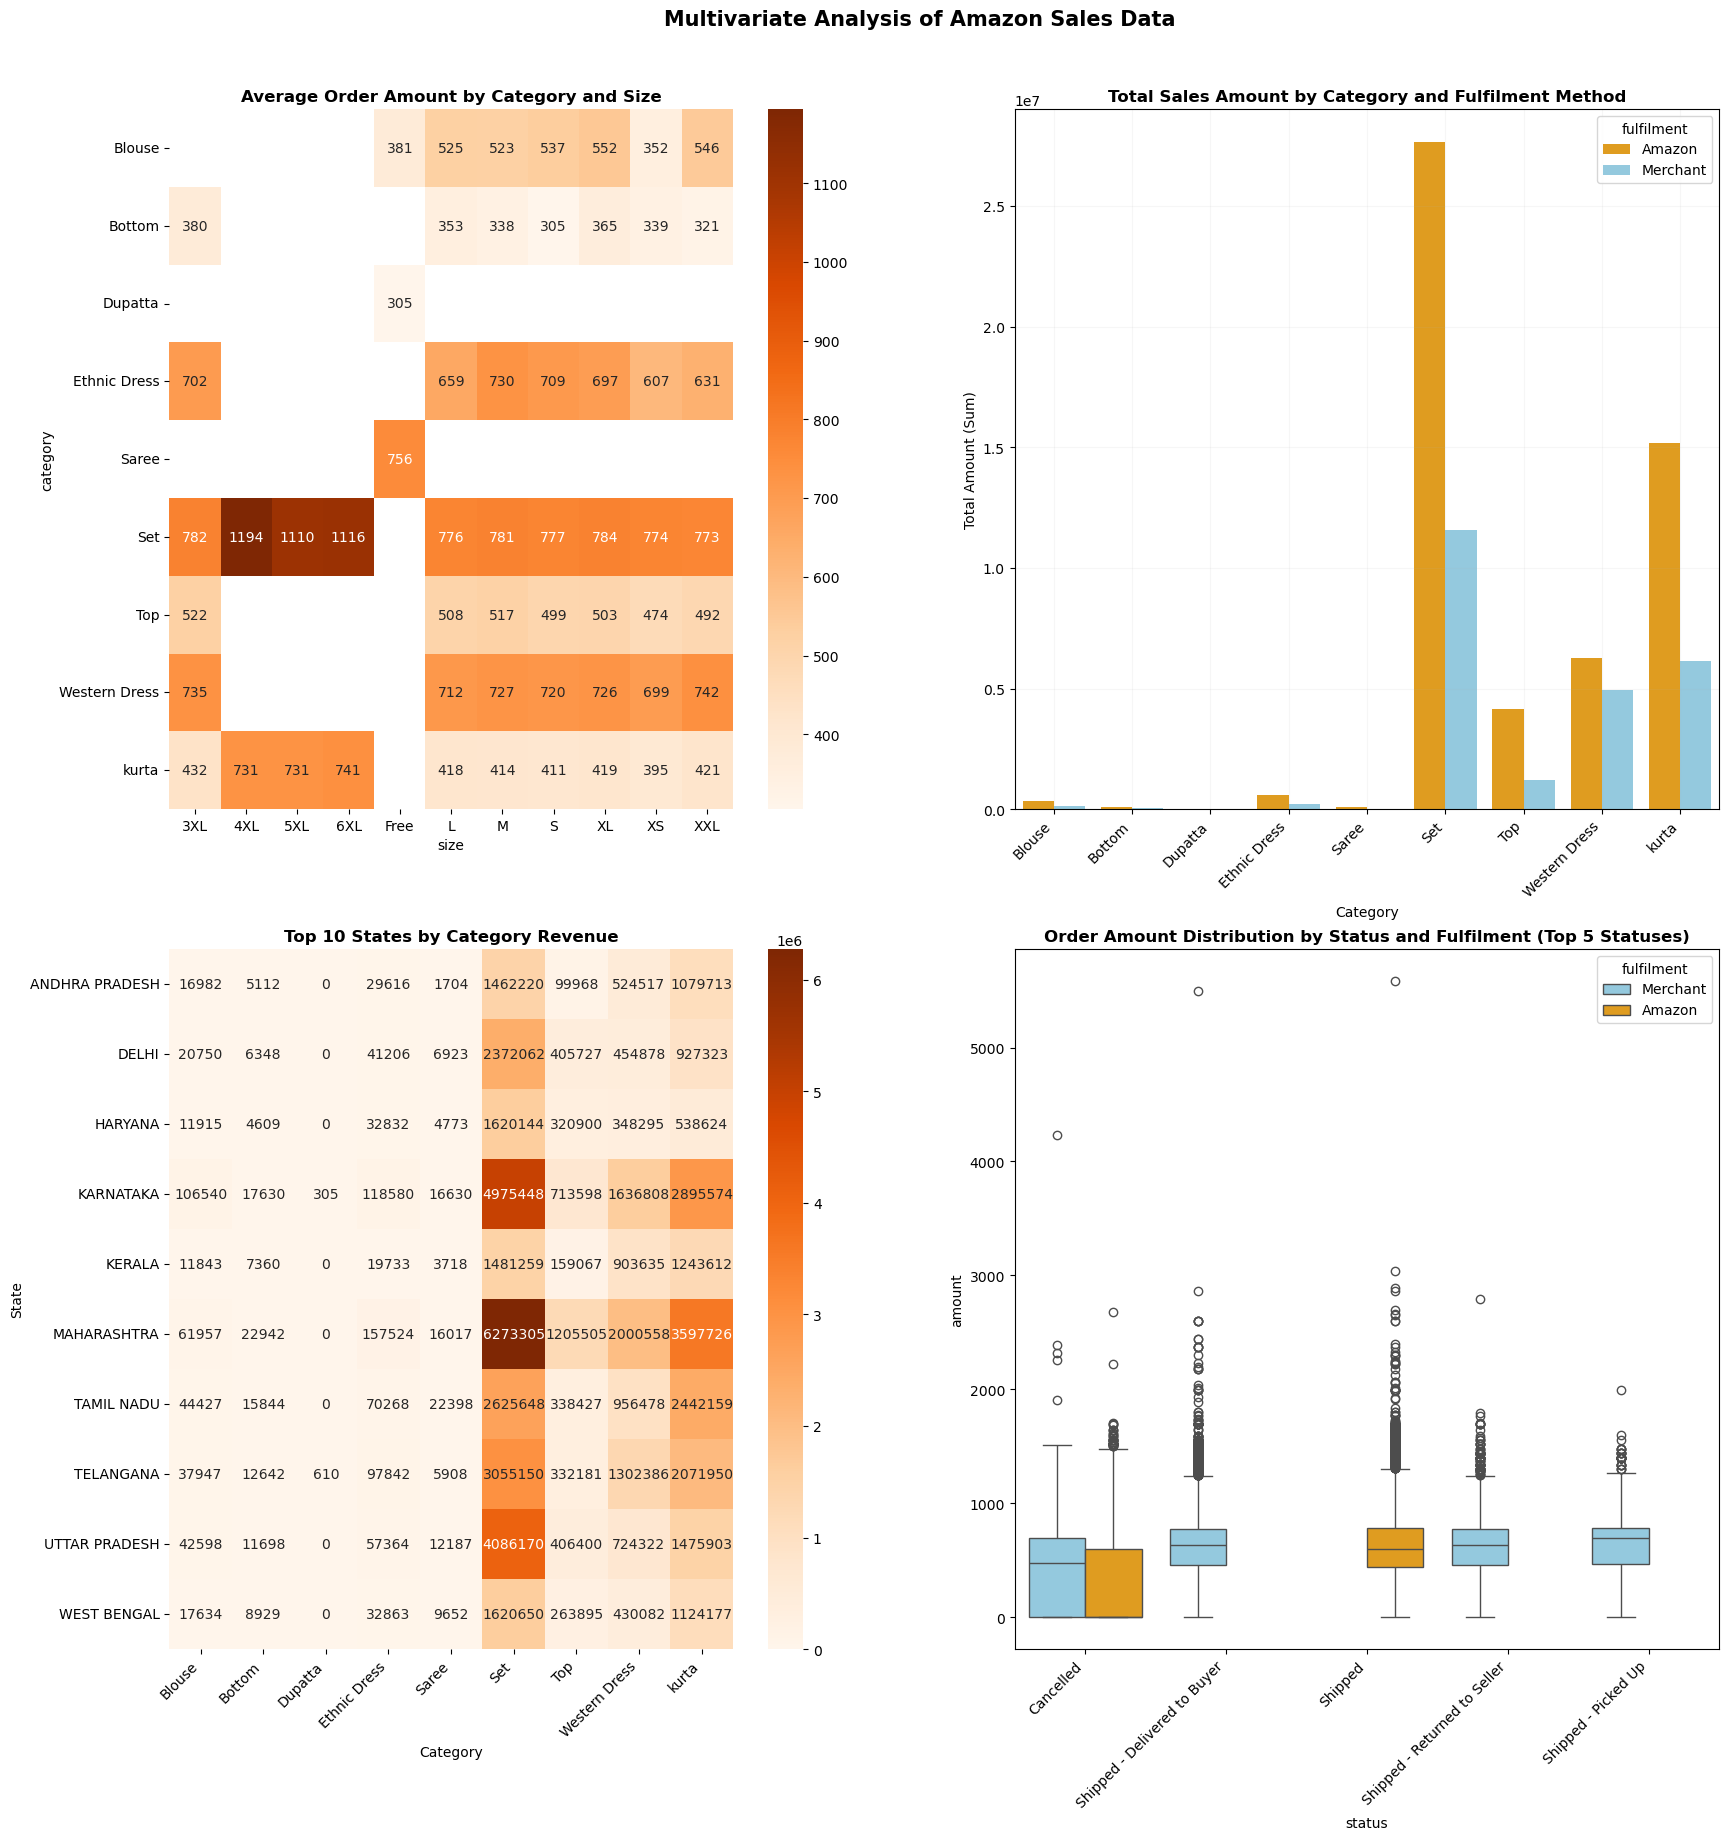

In [28]:
# Analysis combined effects of three or above variables

            
# Create 3 by 3 subplots
fig, axes = plt.subplots(2,2, figsize=(20, 20))
fig.suptitle('Multivariate Analysis of Amazon Sales Data', fontsize=15, fontweight='bold', y=0.93)

# 1. Heatmap: Average Amount by Category and Size
# Helps identify which size/category combinations are most premium
pivot_table = amazon_df.pivot_table(values='amount', index='category', columns='size', aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='Oranges', ax=axes[0, 0])

# Display the title
axes[0, 0].set_title('Average Order Amount by Category and Size', fontsize=12, fontweight='bold')
axes[0, 0].set_yticklabels(axes[0, 0].get_yticklabels(), rotation=0, ha='right', fontsize=10)

# 2. Grouped Bar Chart: Total Sales by Category and Fulfilment
# Compares revenue contribution of fulfilment methods across categories
category_fulfilment = amazon_df.groupby(['category', 'fulfilment'])['amount'].sum().reset_index()

sns.barplot(data=category_fulfilment, x='category', y='amount', hue='fulfilment', palette=['orange', 'skyblue'], ax=axes[0, 1])

# Display the title, x/y label, and grid
axes[0, 1].set_title('Total Sales Amount by Category and Fulfilment Method', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].set_ylabel('Total Amount (Sum)')
axes[0, 1].grid(True, alpha=0.1)
 
# 3. Box Plot: Amount Distribution by Status and Fulfilment
# Visualizes price outliers and median values across order lifecycles
top_statuses = amazon_df['status'].value_counts().nlargest(5).index
df_subset = amazon_df[amazon_df['status'].isin(top_statuses)]

sns.boxplot(data=df_subset, x='status', y='amount', hue='fulfilment', palette=['skyblue', 'orange'], ax=axes[1, 1])

#Display the title, x/y label, and grid
axes[1, 1].set_title('Order Amount Distribution by Status and Fulfilment (Top 5 Statuses)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right');


# 4. Heatmap: Amount Distribution by Top 10 States and Category
# First determine total revenue per state
top_states = ( amazon_df.groupby('ship_state')['amount'].sum().sort_values(ascending=False).head(10).index)
# Then fFilter dataset for only top 10 states
filtered_df = amazon_df[amazon_df['ship_state'].isin(top_states)]
# Group state and category from the above df
state_cat_rev = (filtered_df.groupby(['ship_state', 'category'])['amount'].sum().reset_index())
# Pivot
pivot_state = state_cat_rev.pivot(index='ship_state', columns='category', values='amount').fillna(0)

# Plot the heatmap

sns.heatmap(pivot_state, cmap='Oranges', annot=True, fmt='.0f', ax=axes[1, 0])

# Display the title, x/y label, and grid
axes[1, 0].set_title('Top 10 States by Category Revenue', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('State')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right');

**INTERPRETATIONS** 

*1) Average Order Amount by Category and Size*

        - Sets, Ethinic, and Western dresses are the high valued categories. Particularly, the sets category consistently has the highest average order amounts across nearly all sizes.
        - Bottoms and Dupatta categories are the lowest valued. 
        - Considering  size, plus sizes (3XL-6XL) show high order amounts, and XS and Free sizes show lower amounts, while standard sizes (S - L) have medium order amount.
        - Buyers with large sizes tend to spend more money especially on Sets, Ethinc Dress and Saree.
        - Western Dress and Tops show consistent spending across almost all sizes.

*2) Total Sales Amount by Category and Fulfilment Method*

        - Across nearly all categories, Amazon fulfillment dominates Merchant fulfillment. 
        - Sets and Kurtas generate high revenue with Amazon fulfillment, but sets are outstanding. 
        - Blouse, Bottom, Dupatta, and Saree show low sales amount even if Amazon fulfilment is used. 
        
*3) Top 10 States by Category Revenue*

        - Maharashtra, Karnataka, Uttar Pradesh, and Telangana are the top four states that contributes to the revenue.
        - Maharashtra leads in the overall revenue with strong performance across nearly in all categories.
        - Dupatta is the extreme lowest catagory across all states, often zero.
        
*4) Order Amount Distribution by Status and Fulfilment (Top 5 Statuses)*

        - Amazon concentrated in Shipped and Cancelled which indicates Amazon’s process flow is streamlined, but it also faces cancellations.
        - Merchant has more diverse statuses which indicates Merchant fulfillment tracks more granular outcomes, but with lower order overall amounts.

**KEY INSIGHTS**

        - Customers buying larger sizes tend to spend more per order, especially in Sets and Kurtas.
        - High-value categories, like Sets, Western Dress, Ethnic Dress, show consistent high pricing across sizes, while lower-value categories remain flat.
        - Maharashtra and Karnataka dominate, Sets and Kurtas lead across all states.
        - Amazon faces higher value cancellations while Merchant tracks more granular statuses.

### 4.5. Trend Detection

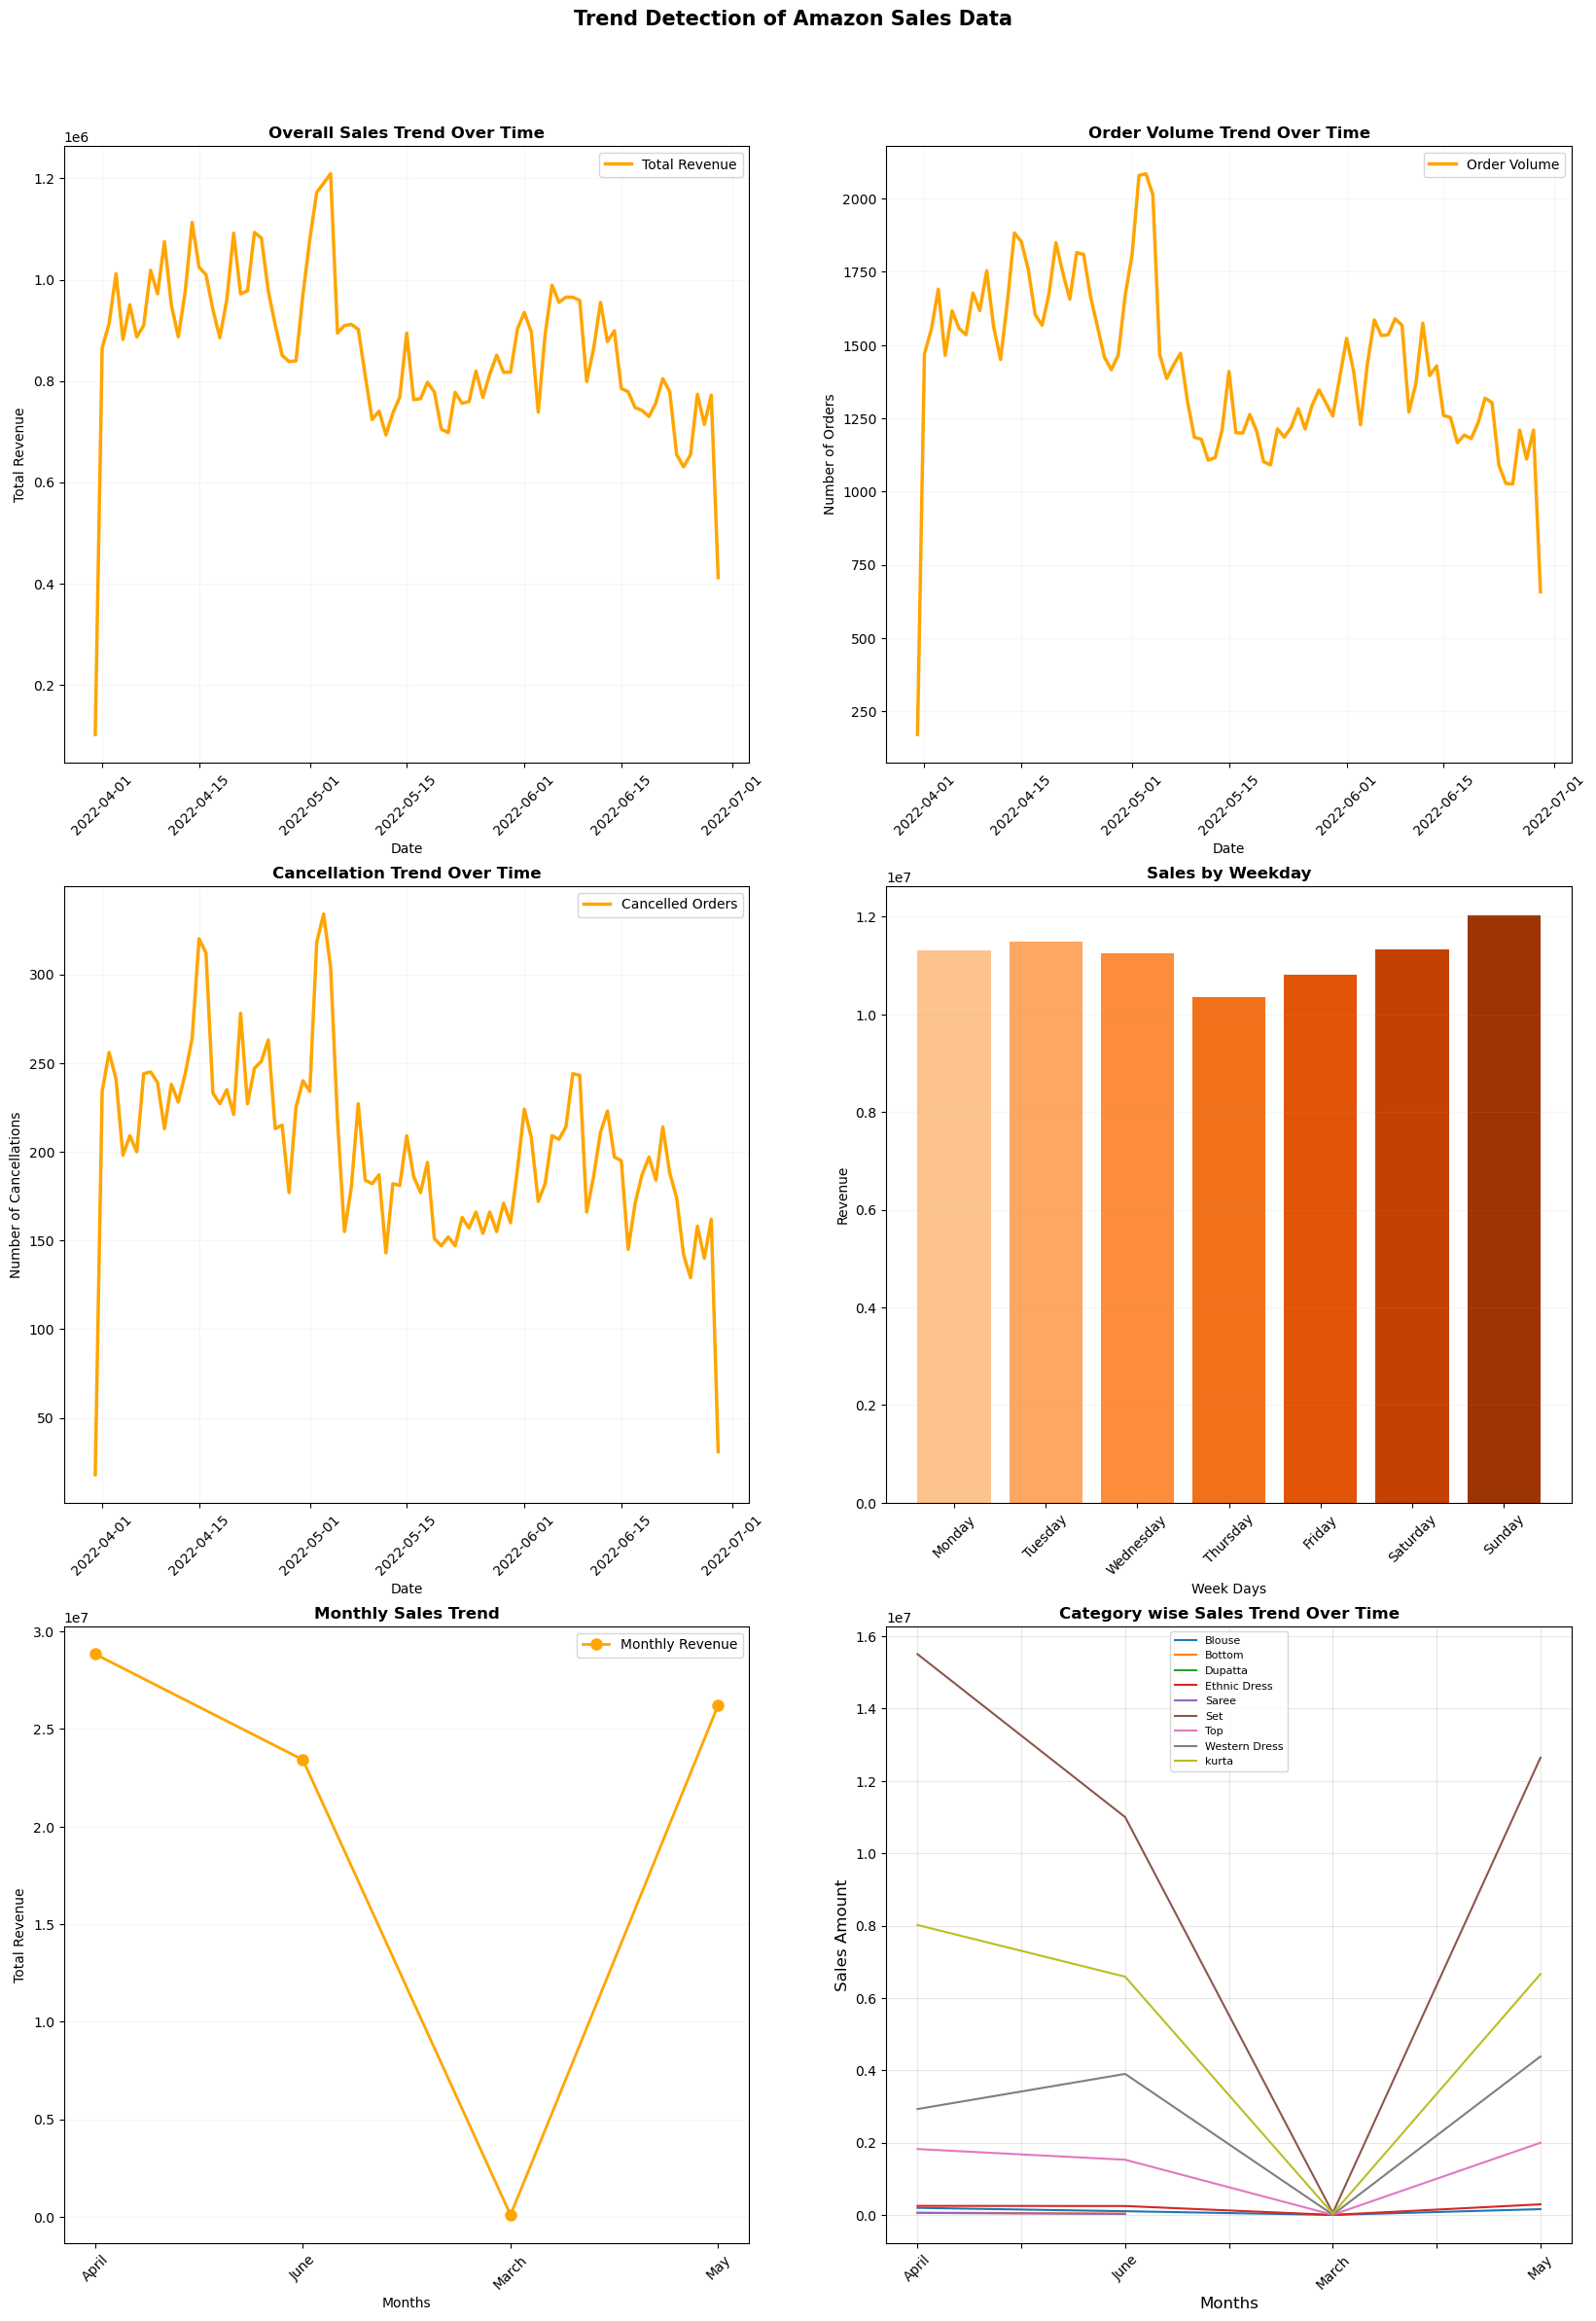

In [29]:
# Time-based analysis
# Create 3 by 3 subplots
fig, axes = plt.subplots(3,2, figsize=(20, 28))
fig.suptitle('Trend Detection of Amazon Sales Data', fontsize=15, fontweight='bold', y=0.93)

# 1. Overall Sales Trend Over Time
sales_trend = amazon_df.groupby('date')['amount'].sum()
axes[0, 0].plot(sales_trend.index, sales_trend.values, color='orange', label='Total Revenue', linewidth=2.5)

# Display the title, x/y label, and grid
axes[0, 0].set_title('Overall Sales Trend Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Total Revenue', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.1)
axes[0, 0].legend() 

# 2. Order Volume Over Time Trend
order_trend = amazon_df.groupby('date')['order_id'].count()
axes[0, 1].plot(order_trend.index, order_trend.values, color='orange', label='Order Volume', linewidth=2.5)

# Display the title, x/y label, and grid
axes[0, 1].set_title('Order Volume Trend Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Date', fontsize=10)
axes[0, 1].set_ylabel('Number of Orders', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.1)
axes[0, 1].legend()

# 3. Cancellation Trend Over Time
# First filter cancelled orders
cancel_df = amazon_df[amazon_df['status'] == 'Cancelled']

# Then count cancellations per day
cancel_trend = cancel_df.groupby('date')['order_id'].count()

axes[1, 0].plot(cancel_trend.index, cancel_trend.values, color='orange', label='Cancelled Orders', linewidth=2.5)

# Display the title, x/y label, and grid
axes[1, 0].set_title('Cancellation Trend Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date', fontsize=10)
axes[1, 0].set_ylabel('Number of Cancellations', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.1)
axes[1, 0].legend()

# 4. Sales by Weekday
# define week days in order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_sales = amazon_df.groupby('week_days')['amount'].sum().reindex(day_order)
colors = plt.cm.Oranges(np.linspace(0.3, 0.9, 7))

# Group and reorder
weekday_sales = amazon_df.groupby('week_days')['amount'].sum().reindex(day_order)

# Create color gradient (optional - Monday darker, Sunday lighter)
colors = plt.cm.Oranges(np.linspace(0.3, 0.9, 7))

# Display the title, x/y label, and grid
axes[1, 1].bar(weekday_sales.index, weekday_sales.values, color=colors)
axes[1, 1].set_title('Sales by Weekday', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Week Days', fontsize=10)
axes[1, 1].set_ylabel('Revenue', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.1)

# 5. Monthly Sales Trend
monthly_sales = amazon_df.groupby('month_name')['amount'].sum()

axes[2, 0].plot(monthly_sales.index, monthly_sales.values, color = 'orange', label='Monthly Revenue', marker='o', 
                linestyle='-', linewidth=2, markersize=8)

# Display the title, x/y label, and grid
axes[2, 0].set_title('Monthly Sales Trend', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Months', fontsize=10)
axes[2, 0].set_ylabel('Total Revenue', fontsize=10)
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].grid(axis='y', alpha=0.1)
axes[2, 0].legend()

# 6. Category wise Sales Trend Over Time
#First group by Month and Category
category_trend = amazon_df.groupby(['month_name', 'category'])['amount'].sum().reset_index()

# Then pivot for plotting
pivot_table = category_trend.pivot(index='month_name', columns='category', values='amount')

# Display the title, x/y label, and grid
pivot_table.plot(ax=axes[2, 1])

axes[2, 1].set_title('Category wise Sales Trend Over Time', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Months', fontsize=12)
axes[2, 1].set_ylabel('Sales Amount', fontsize=12)
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend(loc='best', fontsize=8);

**INTERPRETATIONS** 

*1) Overall Sales Trend Over Time*

        - Revenue fluctuates between April and July 2022.
        - There’s a peak in early May, suggesting a strong sales period.
        - After May, revenue shows declines and volatility, with a noticeable drop toward late June.
        - By July 1, revenue is at one of its lowest points in the period.

*2) Order Volume Trend Over Time*

        - Order volume follows a similar pattern to revenue, peaking around early May.
        - The decline in order volume toward late June mirrors the revenue drop, showing that fewer orders directly led to lower sales

*3) Cancellation Trend Over Time*

        - Cancellations rise and fall between April and July 2022.

        - Mid-April and early May show noticeable points in cancellations.

        - By late June, cancellations drop sharply, suggesting improved order completion or reduced demand.

*4) Sales by Weekday*

        - Sunday generates the highest revenue day, followed closely by Saturday.
        - Thursday is the weakest day, with significantly lower revenue.

*5) Monthly Sales Trend*

        - March is a sharp drop month, which shows lowest point in the period.
        - April is a surge in demand month.
        - In May revenue remains healthy with slightly below April.
        - In June there is noticeable decline again that shows volatility in monthly performance.

*6) Category wise Sales Trend Over Time*

        - Saree and Kurta have the highest revenue categories across months which indicates that they drive the bulk of sales.
        - Set, Western Dress, Ethnic Dress show moderate but steady contributions.
        - Blouse, Bottom, Dupatta, Top have lower revenue categories, with minimal impact compared to Saree and Kurta.
        - All categories dip in March, confirming that the downturn was market-wide, not category-specific.
        - Most categories bounce back in May, especially Saree and Kurta, reinforcing their importance.

**KEY INSIGHTS**

        - The business experienced a short period boom but struggled to maintain growth afterward.
        - A decline in both revenue and order volume suggests either seasonality, reduced promotions, or weaker customer engagement after May.
        - There is strong weekend shopping behavior which may be due to leisure time.
        - Sales dropped sharply in March across all categories, peaked strongly in April, recovered somewhat in May, and declined again in June, with Sets and Kurtas consistently leading performance.

## 5. Business Recommendations

•	Encourage upselling and bundling, since most orders are small (boost average valued sales).

•	Even though they are rare, target premium loyal buyers to increase revenue. 

•	Introduce minimum order thresholds to lift the median closer to the mean.

•	Prioritize stock for M, L, and XL sizes, as they are the focus for inventory planning.

•	Promote smaller sizes (XS and S).

•	Pair niche sizes with high-demand categories (like Sets or Kurtas) to improve sell-through.

•	Reduce cancellations by investigating and addressing causes.

•	Since many orders are shipped but not yet delivered, focus on last-mile efficiency and customer support to ensure more orders to completion.

•	Although returns, rejections, and damages may be few, they can erode customer trust; tracking and minimizing them is beneficial.

•	As there is clear demand on Sets and kurtas prioritize inventory.

•	To increase visibility for low demand categories like Bundle Blouse, Bottom, Saree, and Dupatta, pair them with high demand categories. 

•	Use promotions to boost weaker categories. 

•	Align promotions with high-traffic days (weekends) to maximize impact.

•	Improve delivery speed, reliability, and customer communication to grow Merchant’s market share.

•	While Sets dominate, maintaining balance across categories ensures resilience against seasonal or trend shifts.

•	Ensure promotions are designed to maximize volume without compromising profitability.

•	With lower cancellation rates and higher trust, continue prioritizing Amazon fulfillment for high-value categories.

•	B2B are steadier in volume but are minimal, hence build tailored offerings by exploring bulk deals or partnerships.

•	To avoid risks, reduce outliers by monitoring extreme transactions for pricing errors or fraud. Or use segmentation: target high value customers with premium collections and low value customers with bundles or promotions.

•	Continue prioritizing Sets with Amazon fulfillment, as they are the strongest revenue drivers.

•	Double down on Maharashtra and Karnataka states since they are the top performing states by prioritizing inventory, promotions, and fulfillment here.

•	Since Amazon experiences higher cancellation, reduce them by focusing on improving customer communication, payment reliability, and delivery speed.

•	Identify the factors that caused the peak in April-May and apply those strategies consistently. 

•	Better planning and communication during high demand periods will reduce cancellations and protect revenue reduction.

•   Re-engage April–May buyers with loyalty offers to prevent decline in June.